In [2]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun, ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [4]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [5]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #which agent should go next 

In [6]:
# Create simple tools 

# Initialize the tools
arxiv_tool = ArxivAPIWrapper()
wiki_tool = WikipediaAPIWrapper()
ddg_tool = DuckDuckGoSearchRun()

@tool
def search_arxiv(query: str) -> str:
    """Search Arxiv for academic papers related to the query."""
    results = arxiv_tool.run(query, max_results=3)
    return str(results)

@tool
def search_wikipedia(query: str) -> str:
    """Search Wikipedia for information about the query."""
    results = wiki_tool.run(query)
    return str(results)

@tool
def search_duckduckgo(query: str) -> str:
    """Search the web using DuckDuckGo for general information."""
    results = ddg_tool.run(query, max_results=3)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary


In [7]:
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x00000191295FFB10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001912961E690>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [11]:
# Define agent functions

def research_agent(state: AgentState):
    """Research agent that gathers information"""
    
    messages = state["messages"]
    
    system_msg = SystemMessage(
        content=(
            "You are a research assistant. Use the search tools "
            "(search_arxiv, search_wikipedia, search_duckduckgo) to find information about the user's request."
        )
    )
    
    research_llm = llm.bind_tools([search_arxiv, search_wikipedia, search_duckduckgo])
    response = research_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "analysis_agent"
    }

In [12]:
def analysis_agent(state: AgentState):
    """Analysis agent that extracts insights from gathered data"""
    
    messages = state["messages"]
    
    system_msg = SystemMessage(
        content=(
            "You are an analysis assistant. Review the gathered information and extract key insights or important points."
        )
    )
    
    analysis_llm = llm.bind_tools([write_summary])
    response = analysis_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "summary_agent"
    }

In [13]:
def summary_agent(state: AgentState):
    """Summary agent that creates a final summary"""
    
    messages = state["messages"]
    
    system_msg = SystemMessage(
        content="You are a technical writer. Create a clear and concise summary of the findings."
    )
    
    summary_llm = llm.bind_tools([write_summary])
    response = summary_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [14]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_arxiv, search_wikipedia, search_duckduckgo, write_summary])
        response = tool_node.invoke(state)
        return response
    
    return state

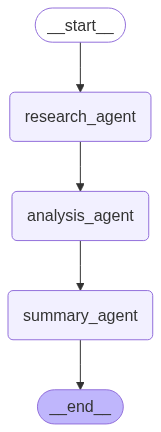

In [15]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("research_agent", research_agent)
workflow.add_node("analysis_agent", analysis_agent)
workflow.add_node("summary_agent", summary_agent)

# Define flow
workflow.set_entry_point("research_agent")
workflow.add_edge("research_agent", "analysis_agent")
workflow.add_edge("analysis_agent", "summary_agent")
workflow.add_edge("summary_agent", END)

# Compile the workflow
final_workflow = workflow.compile()

final_workflow


In [29]:
# Run the research agent (produces tool_call)
state = research_agent({
    "messages": [HumanMessage(content="Explore the benefits and challenges of using agentic AI in enterprise decision-making")]
})
# Execute any pending tool calls (actually runs write_summary)
state = execute_tools(state)
# Pass the updated state to analysis agent
state = analysis_agent(state)
# Execute any tool calls from analysis agent (if any)
state = execute_tools(state)
# Pass the updated state to summary agent
state = summary_agent(state)
# Execute summary_agent's tool calls (if any)
state = execute_tools(state)
# Print final output
for msg in state.get("messages", []):
    print(msg.content)


c:\Users\Jesut\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Summary of findings:

Agentic AI is a class of artificial intelligence that focuses on autonomous systems that can make decisions and perform tasks without human intervention. The field is closely linked to agentic automation, also known as agent-based process management systems, when applied to process automation. Applications include software development, customer support, cybersecurity and business intelligence....
Summary of findings:

Manus (meaning hands in Latin) is an autonomous artificial intelligence agent developed by the same startup that created Monica, headquartered in Singapore. The agent is designed to independently carry out complex real-world tasks without direct or continuous human guidance. It is recognized as one of the world's first autonomous agents capable of independent thinking, dynamic planning, and decision-making....
Summary of findings:

Automated decision-making (ADM) is the use of data, machines and algorithms to make decisions in a range of contexts, in